## **Capstone Project**
#### Timothy Vermette



### **Housing Affordability Across 100 Major United States Metrpolitan Areas**
#### Housing affordability has become an increasingly important economic and social issue in the United States. The purpose of this project is to explore factors that are most strongly associated with the ability to achieve the “American Dream” of home ownership. Using data from Zillow and the U.S. Census Bureau, this analysis will explore relationships among home values, median household income, educational attainment, and population, across the top 100 largest metropolitan areas in the U.S. The goal is to obtain a better understanding of the factors associated with house prices and affordability, to explore population trends, and identify the metropolitan areas where homeownership is more or less attainable.

### **Research Question**
#### What economic factors (home prices, median income, educational attainment) influence American households’ ability to buy a home, and what US cities have become the least and most attainable and populated?

### **Scope of This Analysis**
#### This preliminary notebook consists of 2024 data and a baseline model based on 2024.
#### As part of the final capstone project, the same EDA and methodolgy will be conducted for equivalent datasets for the years 2010 and 2015, in order to explore and compare and contrast trends over the years 2010, 2015, and 2024.

### **Data Sources**
#### Zillow:
##### Zillow Home Value Index (ZHVI). URL: https://www.zillow.com/research/data/

#### Census.gov:
##### Median Household Income Past 12 months 2024. URL https://data.census.gov/table/ACSDT1Y2024.B19013?t=Income+(Households,+Families,+Individuals):Income+and+Earnings&g=010XX00US$31000M1&y=2024

##### Median Household Income Past 12 months 2015. URL https://data.census.gov/table/ACSDT5Y2015.B19013?t=Income+(Households,+Families,+Individuals):Income+and+Earnings&g=010XX00US$31000M1&y=2015

##### Median Household Income Past 12 months 2010. URL https://data.census.gov/table/ACSDT5Y2010.B19013?t=Income+(Households,+Families,+Individuals):Income+and+Earnings&g=010XX00US$31000M1&y=2010

##### Total Population 2024 (Metro). URL https://data.census.gov/table/ACSDT5Y2024.B01003?t=Counts,+Estimates,+and+Projections:Population+Total&g=010XX00US$31000M1&y=2024

##### Total Population 2015 (Metro). URL https://data.census.gov/table/ACSDT5Y2015.B01003?t=Counts,+Estimates,+and+Projections:Population+Total&g=010XX00US$31000M1&y=2015

##### Total Population 2010 (Metro). URL https://data.census.gov/table/ACSDT5Y2010.B01003?t=Counts,+Estimates,+and+Projections:Population+Total&g=010XX00US$31000M1&y=2010

##### Educational Attainment for POP over 25 2024. URL https://data.census.gov/table/ACSDT5Y2024.B15003?t=Educational+Attainment&g=010XX00US$31000M1&y=2024

##### Educational Attainment for POP over 25 2015. URL https://data.census.gov/table/ACSDT5Y2015.B15003?t=Educational+Attainment&g=010XX00US$31000M1&y=2015

##### Educational Attainment for POP over 25 2010. URL https://data.census.gov/table/ACSDT1Y2010.B15003?t=Educational+Attainment&g=010XX00US$31000M1&y=2010



### **EDA, Data Preparation**
#### Housing data from Zillow Home Value Index (ZHVI) and demographic data from U.S. Census Bureau American Community Survey (ACS), including median household income, educational attainment, and population were cleaned, standardized, and merged into a single dataset. 

#### Metropolitan naming conventions were different between Zillow and Census datasets, therefore a Metro Mapping table was developed to reconcile these differences, and to enable clean merging of multiple datasets based on Metropolitan areas. A single dataset of the top 100 Metropolitan Areas for 2024 was created. 

#### **Additional feature engineering was completed to create variables**
#### **"Price to Income Ratio"** calculated by dividing median home value by median household income, to provide a measure of affordability.
#### **"College Education Percentage"** consisting of percentage of adults 25 years and older that possess a Bachelor's Degree or higher.

#### *This data preparation can be viewed in the additional Jupyter Notebook titled "Capstone Dataset Exploration".*

### **Final Analytical Dataset for 2024**

In [1]:
import pandas as pd

analysis_2024_top100 = pd.read_csv(
    "Data Intermediate/analysis_2024_top100.csv"
)

analysis_2024_top100.head()

,RegionID,SizeRank,Metro,RegionType,StateName,Date,HomeValue,Year,CensusMetro,Income2024,Population2024,CollegeEducated2024,CollegeEducatedPct,PriceToIncomeRatio
0,394913,1,"New York, NY",msa,NY,2024-12-31,683398.809012,2024,"New York-Newark-Jersey City, NY-NJ",99852.0,19798537.0,6168034,0.311540,6.844117
1,753899,2,"Los Angeles, CA",msa,CA,2024-12-31,980928.090661,2024,"Los Angeles-Long Beach-Anaheim, CA",96405.0,12974487.0,3468765,0.267353,10.175075
2,394463,3,"Chicago, IL",msa,IL,2024-12-31,331370.219996,2024,"Chicago-Naperville-Elgin, IL-IN",90770.0,9371595.0,2696647,0.287747,3.650658
3,394514,4,"Dallas, TX",msa,TX,2024-12-31,385136.186667,2024,"Dallas-Fort Worth-Arlington, TX",92733.0,7985590.0,2067948,0.258960,4.153173
4,394692,5,"Houston, TX",msa,TX,2024-12-31,316340.099352,2024,"Houston-Pasadena-The Woodlands, TX",81417.0,7442788.0,1742444,0.234112,3.885431


### Data Dictionary
| Variable | Description |
|---|---|
| **RegionID** | Zillow’s unique identifier for each geographic region. |
| **SizeRank** | Zillow’s ranking of metropolitan areas by size, with lower numbers representing larger metros. |
| **Metro** | Zillow metropolitan area name. |
| **RegionType** | Zillow geographic classification for the region, such as metropolitan area. |
| **StateName** | State associated with the metropolitan area. |
| **Date** | Zillow monthly observation date. For this analysis, all records use the year-end date `2024-12-31`. |
| **HomeValue** | Zillow Home Value Index (ZHVI) estimate for the metropolitan area in December 2024. |
| **Year** | Calendar year associated with the selected Zillow observation. |
| **CensusMetro** | Census metropolitan area name used to match and merge ACS data with Zillow data. |
| **Income2024** | Median household income for the metropolitan area from the 2024 ACS 5-year estimates. |
| **Population2024** | Total metropolitan population from the 2024 ACS 5-year estimates. |
| **CollegeEducated2024** | Number of adults age 25 and older with a bachelor’s degree or higher. |
| **CollegeEducatedPct** | Percentage of adults age 25 and older with a bachelor’s degree or higher. |
| **PriceToIncomeRatio** | Home value divided by median household income; used as a measure of housing affordability. |

## Exploratory Data Analysis

In [2]:
analysis_2024_top100.shape

(100, 14)

In [3]:
analysis_2024_top100.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   RegionID             100 non-null    int64  
 1   SizeRank             100 non-null    int64  
 2   Metro                100 non-null    object 
 3   RegionType           100 non-null    object 
 4   StateName            100 non-null    object 
 5   Date                 100 non-null    object 
 6   HomeValue            100 non-null    float64
 7   Year                 100 non-null    int64  
 8   CensusMetro          100 non-null    object 
 9   Income2024           100 non-null    float64
 10  Population2024       100 non-null    float64
 11  CollegeEducated2024  100 non-null    int64  
 12  CollegeEducatedPct   100 non-null    float64
 13  PriceToIncomeRatio   100 non-null    float64
dtypes: float64(5), int64(4), object(5)
memory usage: 11.1+ KB


In [4]:
analysis_2024_top100.describe()

,RegionID,SizeRank,HomeValue,Year,Income2024,Population2024,CollegeEducated2024,CollegeEducatedPct,PriceToIncomeRatio
count,100.000000,100.000000,1.000000e+02,100.0,100.00000,1.000000e+02,1.000000e+02,100.000000,100.000000
mean,405550.450000,51.630000,4.163581e+05,2024.0,85267.79000,2.238525e+06,6.130484e+05,0.254303,4.689024
std,61572.804864,29.989444,2.213067e+05,0.0,16546.11524,2.767194e+06,8.354369e+05,0.055538,1.445360
min,394304.000000,1.000000,1.911165e+05,2024.0,56720.00000,4.628150e+05,6.963300e+04,0.115608,2.891542
25%,394508.500000,25.750000,2.727046e+05,2024.0,74274.75000,7.956740e+05,1.725638e+05,0.225169,3.645864
50%,394846.000000,51.500000,3.613780e+05,2024.0,82079.50000,1.157228e+06,2.803215e+05,0.251356,4.413425
75%,395034.500000,77.250000,4.673956e+05,2024.0,92441.25000,2.460202e+06,7.233102e+05,0.280250,5.168014
max,753924.000000,103.000000,1.679506e+06,2024.0,164801.00000,1.979854e+07,6.168034e+06,0.391929,10.191114


In [5]:
analysis_2024_top100.isnull().sum()

RegionID               0
SizeRank               0
Metro                  0
RegionType             0
StateName              0
Date                   0
HomeValue              0
Year                   0
CensusMetro            0
Income2024             0
Population2024         0
CollegeEducated2024    0
CollegeEducatedPct     0
PriceToIncomeRatio     0
dtype: int64

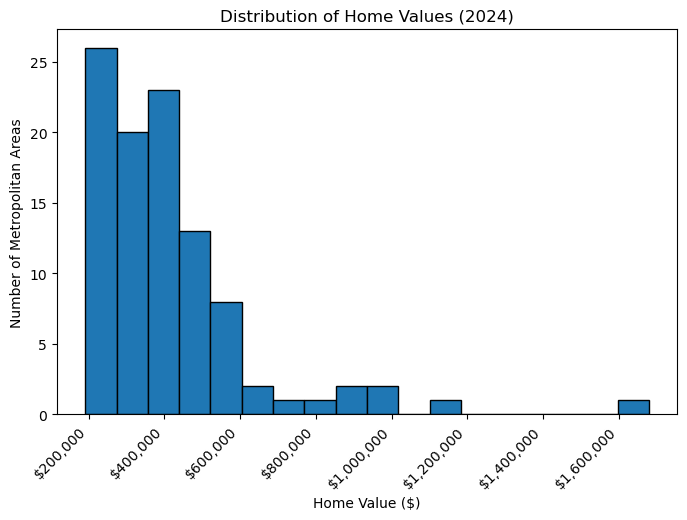

In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.figure(figsize=(8,5))

plt.hist(analysis_2024_top100["HomeValue"],
         bins="auto",
         edgecolor="black")

plt.title("Distribution of Home Values (2024)")
plt.xlabel("Home Value ($)")
plt.ylabel("Number of Metropolitan Areas")

# Format x-axis as currency
ax = plt.gca()
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
plt.xticks(rotation=45, ha="right")

plt.show()

In [7]:
analysis_2024_top100["HomeValue"].describe()

count    1.000000e+02
mean     4.163581e+05
std      2.213067e+05
min      1.911165e+05
25%      2.727046e+05
50%      3.613780e+05
75%      4.673956e+05
max      1.679506e+06
Name: HomeValue, dtype: float64

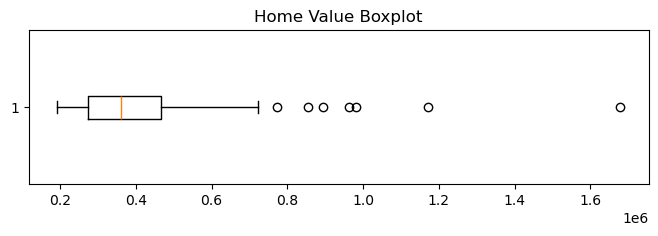

In [8]:
plt.figure(figsize=(8,2))

plt.boxplot(analysis_2024_top100["HomeValue"],
            vert=False)

plt.title("Home Value Boxplot")

plt.show()

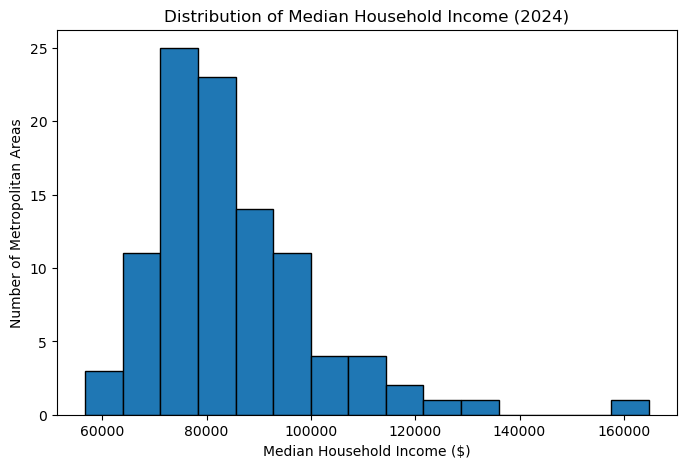

In [9]:
plt.figure(figsize=(8,5))
plt.hist(analysis_2024_top100["Income2024"], bins=15, edgecolor="black")

plt.title("Distribution of Median Household Income (2024)")
plt.xlabel("Median Household Income ($)")
plt.ylabel("Number of Metropolitan Areas")

plt.show()

In [10]:
analysis_2024_top100["Income2024"].describe()

count       100.00000
mean      85267.79000
std       16546.11524
min       56720.00000
25%       74274.75000
50%       82079.50000
75%       92441.25000
max      164801.00000
Name: Income2024, dtype: float64

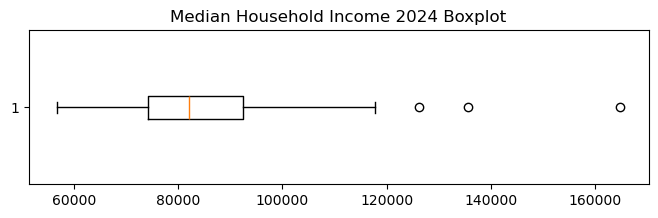

In [11]:
plt.figure(figsize=(8,2))

plt.boxplot(analysis_2024_top100["Income2024"],
            vert=False)

plt.title("Median Household Income 2024 Boxplot")

plt.show()

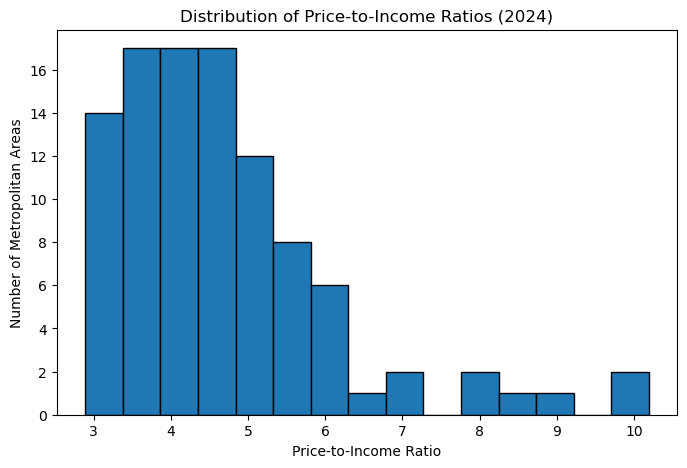

In [12]:
plt.figure(figsize=(8,5))
plt.hist(analysis_2024_top100["PriceToIncomeRatio"],
         bins=15,
         edgecolor="black")

plt.title("Distribution of Price-to-Income Ratios (2024)")
plt.xlabel("Price-to-Income Ratio")
plt.ylabel("Number of Metropolitan Areas")

plt.show()

In [13]:
analysis_2024_top100["PriceToIncomeRatio"].describe()

count    100.000000
mean       4.689024
std        1.445360
min        2.891542
25%        3.645864
50%        4.413425
75%        5.168014
max       10.191114
Name: PriceToIncomeRatio, dtype: float64

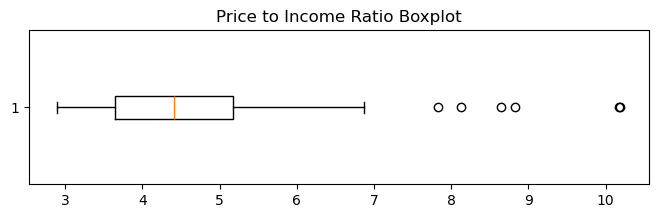

In [14]:
plt.figure(figsize=(8,2))

plt.boxplot(analysis_2024_top100["PriceToIncomeRatio"],
            vert=False)

plt.title("Price to Income Ratio Boxplot")

plt.show()

### Distributions of Home Values, Median Income, Price to Income Ratio
#### The above histograms and boxplots show that the distribution of **Home Values** is right-skewed, which indicates that a relatively small number of metros have significantly higher average home values. **Median Household Income** is slightly right-skewed, and a small number of metros have significantly higher incomes. The engineered feature of **Price to Income Ratio** distribution showcases that affordability based on income and home prices differs across metropolitan areas.

In [15]:
corr = analysis_2024_top100[
    ["HomeValue",
     "Income2024",
     "Population2024",
     "CollegeEducatedPct",
     "PriceToIncomeRatio"]
].corr()

corr

,HomeValue,Income2024,Population2024,CollegeEducatedPct,PriceToIncomeRatio
HomeValue,1.000000,0.875766,0.308403,0.494031,0.933869
Income2024,0.875766,1.000000,0.310985,0.714563,0.698402
Population2024,0.308403,0.310985,1.000000,0.287781,0.328570
CollegeEducatedPct,0.494031,0.714563,0.287781,1.000000,0.308401
PriceToIncomeRatio,0.933869,0.698402,0.328570,0.308401,1.000000


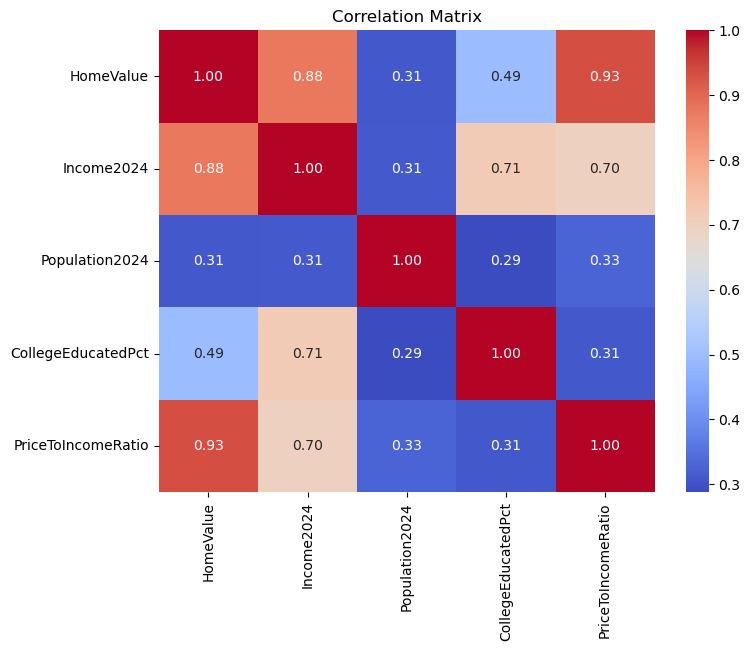

In [16]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

#### Median household income has the strongest positive correlation with home values (r = 0.88), suggesting that wealthier metropolitan areas generally have higher home prices. Educational attainment showed a moderate positive relationship with home values (r = 0.49), but a strong correlation to Median Income (r = 0.71). Population showed a comparatively weak association (r = 0.31) with home values. As expected, the engineered Price-to-Income Ratio was strongly correlated with home values because it is derived directly from home values and household income.

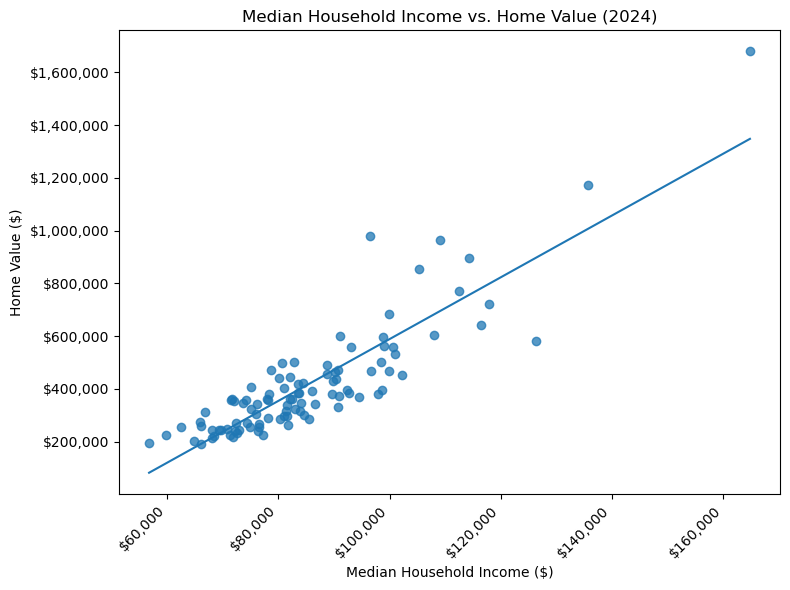

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

x = analysis_2024_top100["Income2024"]
y = analysis_2024_top100["HomeValue"]

plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.75)

# Best-fit line
m, b = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
plt.plot(x_line, m * x_line + b)

plt.title("Median Household Income vs. Home Value (2024)")
plt.xlabel("Median Household Income ($)")
plt.ylabel("Home Value ($)")

ax = plt.gca()
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

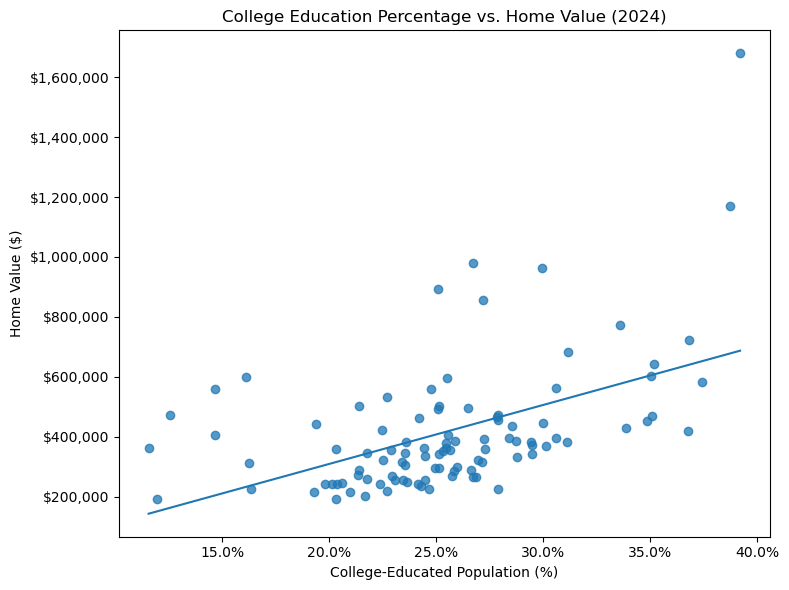

In [18]:
x = analysis_2024_top100["CollegeEducatedPct"]
y = analysis_2024_top100["HomeValue"]

plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.75)

# Best-fit line
m, b = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
plt.plot(x_line, m * x_line + b)

plt.title("College Education Percentage vs. Home Value (2024)")
plt.xlabel("College-Educated Population (%)")
plt.ylabel("Home Value ($)")

ax = plt.gca()
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))

plt.tight_layout()
plt.show()

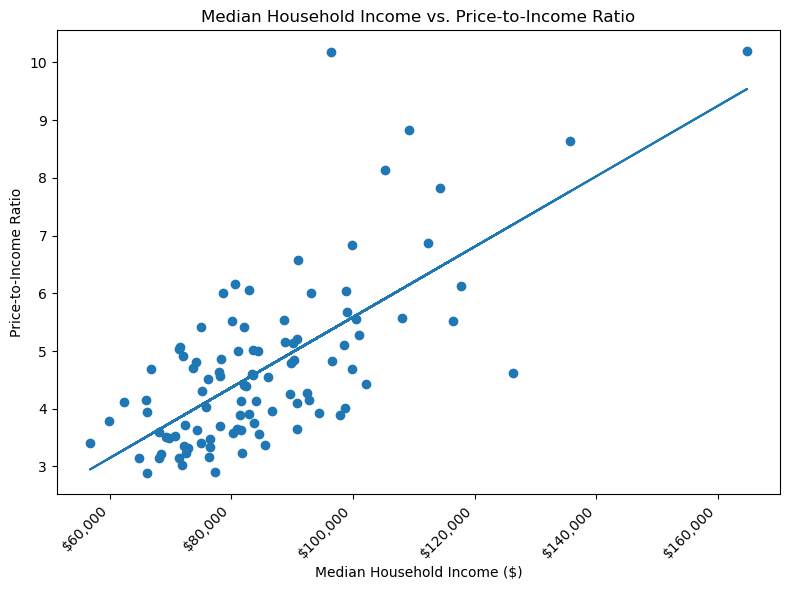

In [19]:
import numpy as np

x = analysis_2024_top100["Income2024"]
y = analysis_2024_top100["PriceToIncomeRatio"]

plt.figure(figsize=(8,6))
plt.scatter(x, y)

# Best-fit line
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)

plt.title("Median Household Income vs. Price-to-Income Ratio")
plt.xlabel("Median Household Income ($)")
plt.ylabel("Price-to-Income Ratio")

ax = plt.gca()
ax.xaxis.set_major_formatter(
    mtick.StrMethodFormatter('${x:,.0f}')
)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#### Scatterplots reinforce our correlation matrix, showing a strong correlation between Median Household Income and Home Values, a weaker although positive relationship between College Educatoin and Home Values, and a strong relationship between our engineered feature, Price to Income Ratio, and Median Household Income.

### Baseline Model

In [20]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_squared_error,
    root_mean_squared_error,
    r2_score
)

In [21]:
X = analysis_2024_top100[
    ["Income2024",
     "Population2024",
     "CollegeEducatedPct"]
]

y = analysis_2024_top100["HomeValue"]

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [23]:
lr = LinearRegression()

In [24]:
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [25]:
train_preds = lr.predict(X_train)
test_preds = lr.predict(X_test)

In [26]:
train_rmse = root_mean_squared_error(y_train, train_preds)
test_rmse = root_mean_squared_error(y_test, test_preds)

r2 = r2_score(y_test, test_preds)

print(f"Train RMSE: ${train_rmse:,.2f}")
print(f"Test RMSE:  ${test_rmse:,.2f}")
print(f"R² Score:   {r2:.3f}")

Train RMSE: $101,851.22
Test RMSE:  $76,016.48
R² Score:   0.804


In [27]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
})

coef_df

,Feature,Coefficient
0,Income2024,1.450067e+01
1,Population2024,5.708200e-03
2,CollegeEducatedPct,-1.228401e+06


In [28]:
coef_df.sort_values(
    "Coefficient",
    key=abs,
    ascending=False
)

,Feature,Coefficient
2,CollegeEducatedPct,-1.228401e+06
0,Income2024,1.450067e+01
1,Population2024,5.708200e-03


In [29]:
print(f"Intercept: {lr.intercept_:,.2f}")

Intercept: -521,210.11


In [30]:
coef_df["Coefficient"] = coef_df["Coefficient"].map(
    lambda x: f"{x:,.2f}"
)

coef_df

,Feature,Coefficient
0,Income2024,14.50
1,Population2024,0.01
2,CollegeEducatedPct,"-1,228,401.09"


### Coefficients
#### Income2024 coefficient of 14.5 indicates that, based on our model, higher median income is associated with higher home values. For every \\$1 increase in median income, home values increase by \\$14.5. Therefore, for every \\$10k increase in median household income, our model predicts that home values increase by about \\$145,000.

#### Population2024 has a coefficient of 0.01 (positive but small) which tells us that population alone is not a strong predictor of home values. We will continue to explore population trends.

#### CollegeEducatedPct has a large negative coefficient, and this should be interpreted with caution. We see above that there is a strong correlation between College Education and Median Income, and our model indicates that there is a strong relationship between income and home values. This does not represent that metros with more college educated people results in an area with lower home values, but rather, more likely, that there is multicollinearity between socioeconomic variables, and additional data would be required to isolate the relationship between home values and education.

### Baseline Model Results
#### Linear Regression model with selected features of Income2024, Population2024, CollegeEducatedPct, with HomeValue as target. The purpose of this Linear Regression baseline model is to begin to evaluate whether the demographic variables of Median Income, Population, and College Education are relevant in explaining variations in home prices among major metrpolitan areas in the U.S.

#### R2 Score of .804 indicates that roughly 80% of the variation in home values can be explained by the features selected.
#### Test RMSE of \\$76,016.48 indicates that our model's predictions differed from actual home values by about \\$76,000.


### Conclusion and Future Work
#### The conclusion of the initial phase of this project of exploring what economic factors are most influential in determning housing affordability begins to tell a story that across major metropolitan areas in the U.S., Median Household Income is the strongest predictor of home values, and although Educational Attainment is not strongly correlated (based on our model), it is imperative to increased median income. Population of metros does not seem to be a significant factor in home values.

#### The baseline Linear Regression model provides a foundation for future work. The final submission of this capstone project will incorporate equivalent datasets from 2010 and 2015, allowing us to explore changes in housing affordability over time. Additional modeling approaches, including Ridge Regression, Lasso Regression, and Polynomial Regression, will also be explored to compare predictive performance and identify the most influential drivers of housing affordability.